# Netflix Data Cleaning & Visualization Project

## Internship Project

**Name:** Snehil Chandra

**Domain:** Data Science

---

### Objective

The objective of this project is to clean the Netflix dataset, handle missing values, remove duplicate records, perform exploratory data analysis (EDA), create visualizations, and derive meaningful insights.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display graphs inside the notebook
%matplotlib inline

In [2]:
df = pd.read_csv("../data/netflix_titles.csv")

In [3]:
# Display first five rows
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
# Check the number of rows and columns
df.shape

(8807, 12)

## Step 3: Explore the Dataset

### 3.1 Display Column Names

In [5]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

### 3.2 Dataset Information

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


### 3.3 Statistical Summary

In [7]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


### 3.4 Missing Values

In [8]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

### 3.5 Duplicate Records

In [9]:
df.duplicated().sum()

np.int64(0)

## Step 4: Data Cleaning

### 4.1 Create a Backup of the Dataset

In [10]:
# Create a backup copy
df_backup = df.copy()

In [11]:
# Count missing values
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [12]:
# Fill missing values in text columns
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

# Fill missing values using the mode (most frequent value)
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

# Remove rows with missing date_added or duration
df = df.dropna(subset=['date_added', 'duration'])

In [13]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [14]:
# Remove duplicate rows
df = df.drop_duplicates()

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.dtypes

show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object

### 4.7 Convert Date Column

In [17]:
df.info()

<class 'pandas.DataFrame'>
Index: 8794 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8794 non-null   str  
 1   type          8794 non-null   str  
 2   title         8794 non-null   str  
 3   director      8794 non-null   str  
 4   cast          8794 non-null   str  
 5   country       8794 non-null   str  
 6   date_added    8794 non-null   str  
 7   release_year  8794 non-null   int64
 8   rating        8794 non-null   str  
 9   duration      8794 non-null   str  
 10  listed_in     8794 non-null   str  
 11  description   8794 non-null   str  
dtypes: int64(1), str(11)
memory usage: 893.1 KB


In [18]:
df['date_added'] = pd.to_datetime(
    df['date_added'],
    format='mixed'
)

In [19]:
df.info()

<class 'pandas.DataFrame'>
Index: 8794 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8794 non-null   str           
 1   type          8794 non-null   str           
 2   title         8794 non-null   str           
 3   director      8794 non-null   str           
 4   cast          8794 non-null   str           
 5   country       8794 non-null   str           
 6   date_added    8794 non-null   datetime64[us]
 7   release_year  8794 non-null   int64         
 8   rating        8794 non-null   str           
 9   duration      8794 non-null   str           
 10  listed_in     8794 non-null   str           
 11  description   8794 non-null   str           
dtypes: datetime64[us](1), int64(1), str(10)
memory usage: 893.1 KB


## Step 5: Save the Cleaned Dataset

In [20]:
# Save the cleaned dataset
df.to_csv("../data/cleaned_netflix_titles.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


# Step 6: Data Visualization

In [21]:
# Set plot style
plt.style.use('ggplot')

# Set figure size
plt.rcParams['figure.figsize'] = (10,6)

## Visualization 1: Distribution of Movies and TV Shows

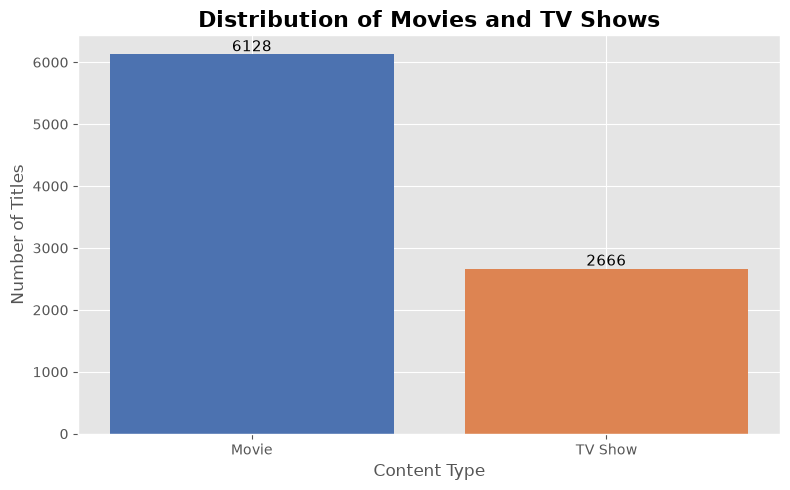

In [22]:
# Count Movies and TV Shows
type_counts = df['type'].value_counts()

plt.figure(figsize=(8,5))

bars = plt.bar(
    type_counts.index,
    type_counts.values,
    color=['#4C72B0', '#DD8452']
)

plt.title("Distribution of Movies and TV Shows", fontsize=16, fontweight='bold')
plt.xlabel("Content Type", fontsize=12)
plt.ylabel("Number of Titles", fontsize=12)

# Display values on top of bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 50,
        int(bar.get_height()),
        ha='center',
        fontsize=11
    )

plt.tight_layout()
plt.show()

## Visualization 2: Content Added by Year

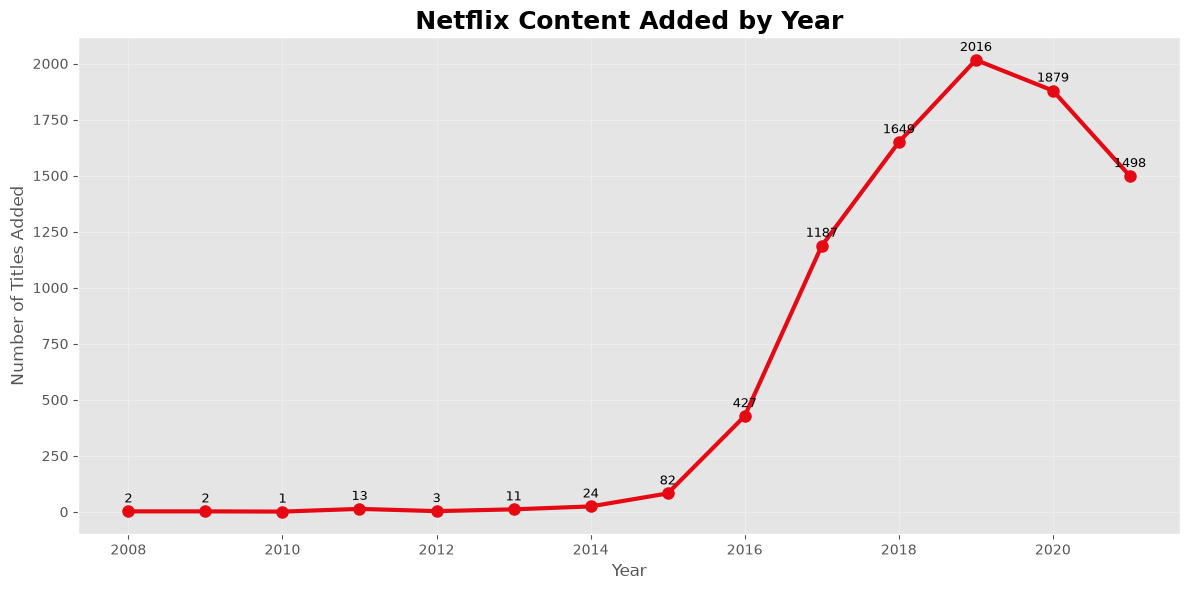

In [23]:
# Extract year from date_added
df['year_added'] = df['date_added'].dt.year

# Count titles added each year
year_added = df['year_added'].value_counts().sort_index()

plt.figure(figsize=(12,6))

plt.plot(
    year_added.index,
    year_added.values,
    marker='o',
    linewidth=3,
    markersize=8,
    color='#E50914'      # Netflix Red
)

plt.title(
    "Netflix Content Added by Year",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Titles Added", fontsize=12)

plt.grid(alpha=0.3)

# Display values on every point
for x, y in zip(year_added.index, year_added.values):
    plt.text(
        x,
        y + 40,
        str(y),
        ha='center',
        fontsize=9
    )

plt.tight_layout()

plt.show()

## Visualization 3: Content Release Year Distribution

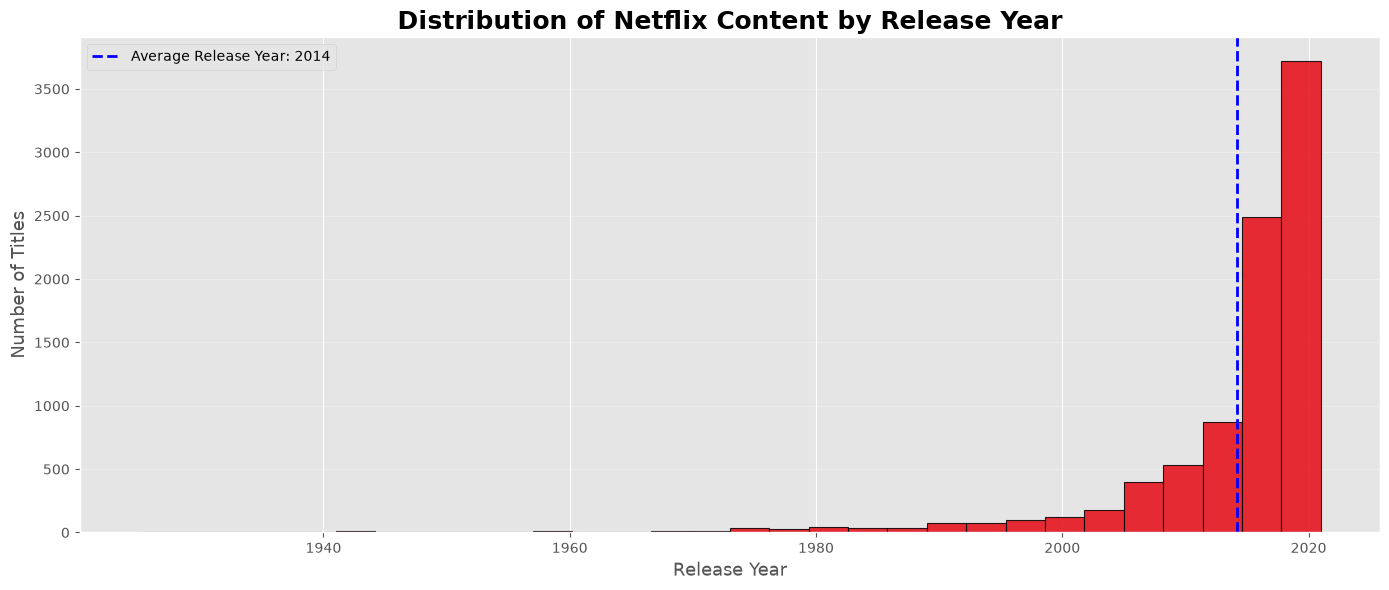

In [24]:
plt.figure(figsize=(14,6))

# Histogram
plt.hist(
    df['release_year'],
    bins=30,
    color="#E50914",      # Netflix Red
    edgecolor="black",
    linewidth=0.8,
    alpha=0.85
)

# Mean release year
mean_year = df['release_year'].mean()

plt.axvline(
    mean_year,
    color="blue",
    linestyle="--",
    linewidth=2,
    label=f"Average Release Year: {int(mean_year)}"
)

plt.title(
    "Distribution of Netflix Content by Release Year",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Release Year", fontsize=13)
plt.ylabel("Number of Titles", fontsize=13)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.grid(axis='y', alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

## Visualization 4: Top 10 Countries with the Most Netflix Content

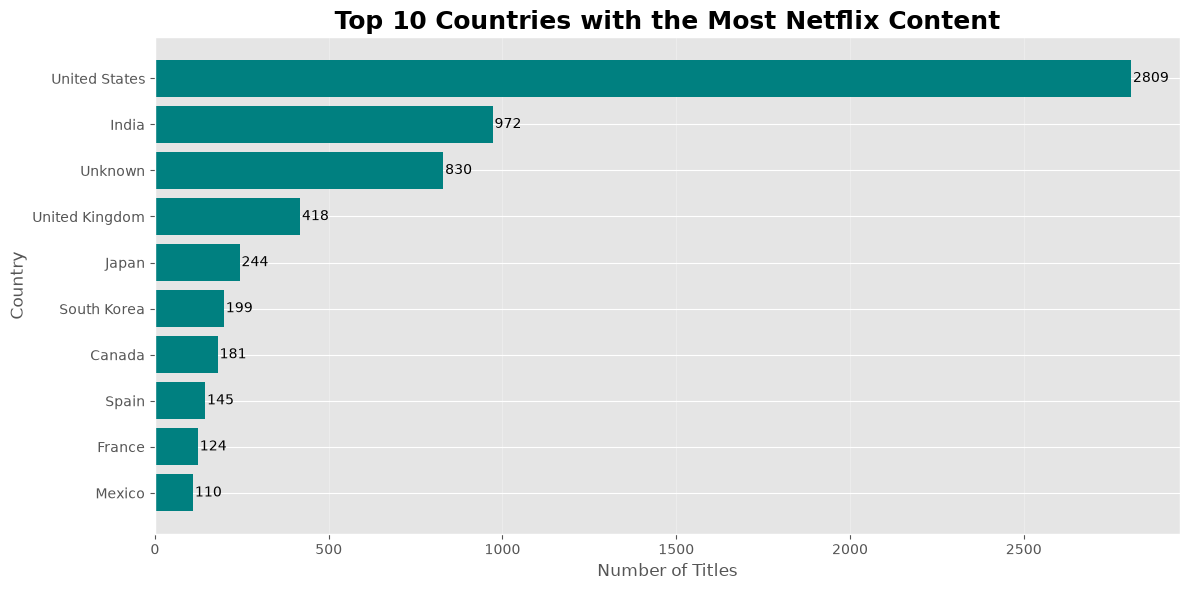

In [25]:
# Get Top 10 Countries
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(12,6))

bars = plt.barh(
    top_countries.index,
    top_countries.values,
    color='teal'
)

plt.title(
    "Top 10 Countries with the Most Netflix Content",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("Number of Titles", fontsize=12)
plt.ylabel("Country", fontsize=12)

# Display values
for bar in bars:
    plt.text(
        bar.get_width() + 5,
        bar.get_y() + bar.get_height()/2,
        int(bar.get_width()),
        va='center',
        fontsize=10
    )

plt.gca().invert_yaxis()

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()

plt.show()

## Visualization 5: Top 10 Genres on Netflix

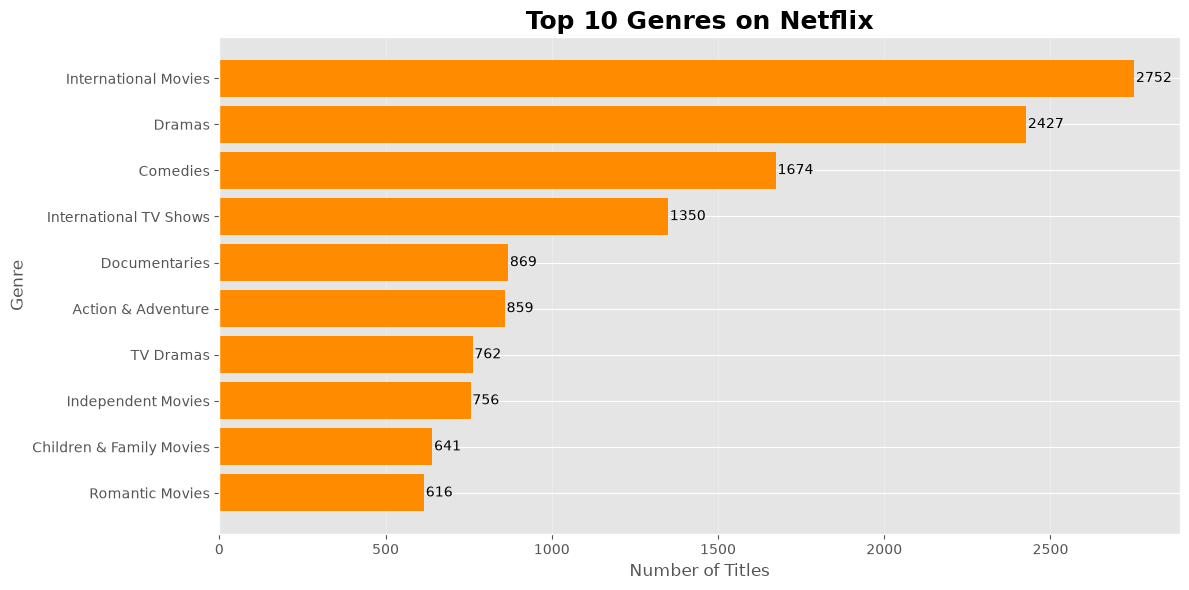

In [26]:
# Split multiple genres and count them
genres = df['listed_in'].str.split(', ').explode()

top_genres = genres.value_counts().head(10)

plt.figure(figsize=(12,6))

bars = plt.barh(
    top_genres.index,
    top_genres.values,
    color='darkorange'
)

plt.title(
    "Top 10 Genres on Netflix",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("Number of Titles", fontsize=12)
plt.ylabel("Genre", fontsize=12)

# Add values
for bar in bars:
    plt.text(
        bar.get_width()+5,
        bar.get_y()+bar.get_height()/2,
        int(bar.get_width()),
        va='center',
        fontsize=10
    )

plt.gca().invert_yaxis()

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()

plt.show()

## Visualization 6: Distribution of Content Ratings

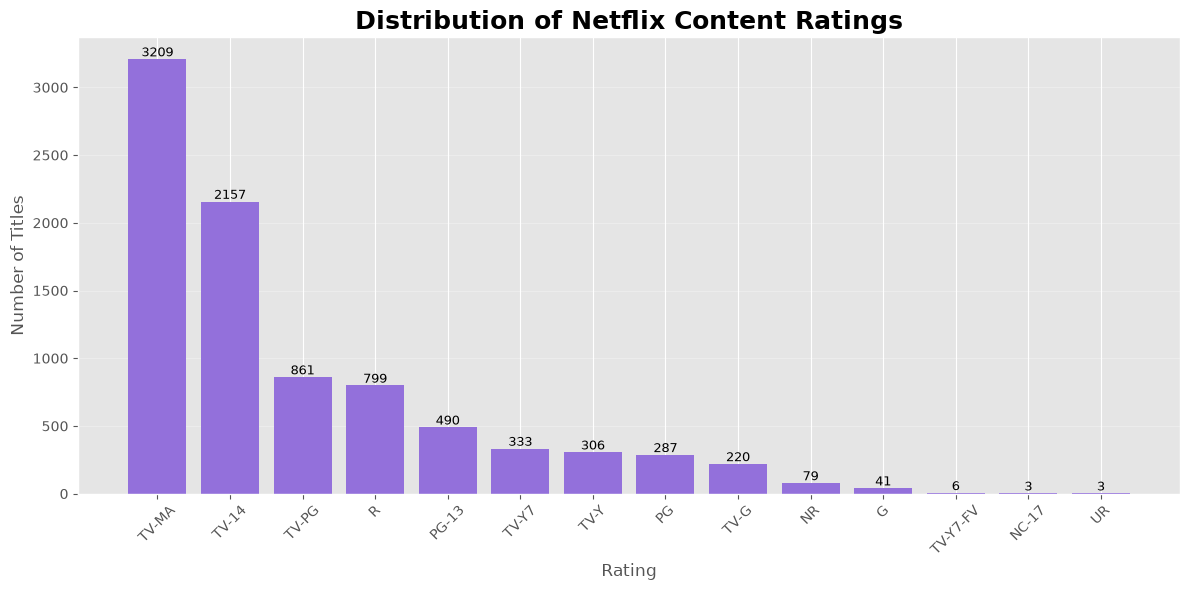

In [27]:
rating_counts = df['rating'].value_counts()

plt.figure(figsize=(12,6))

bars = plt.bar(
    rating_counts.index,
    rating_counts.values,
    color='mediumpurple'
)

plt.title(
    "Distribution of Netflix Content Ratings",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("Rating", fontsize=12)
plt.ylabel("Number of Titles", fontsize=12)

plt.xticks(rotation=45)

# Add values
for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+20,
        int(bar.get_height()),
        ha='center',
        fontsize=9
    )

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.show()

## Visualization 7: Top 10 Directors on Netflix

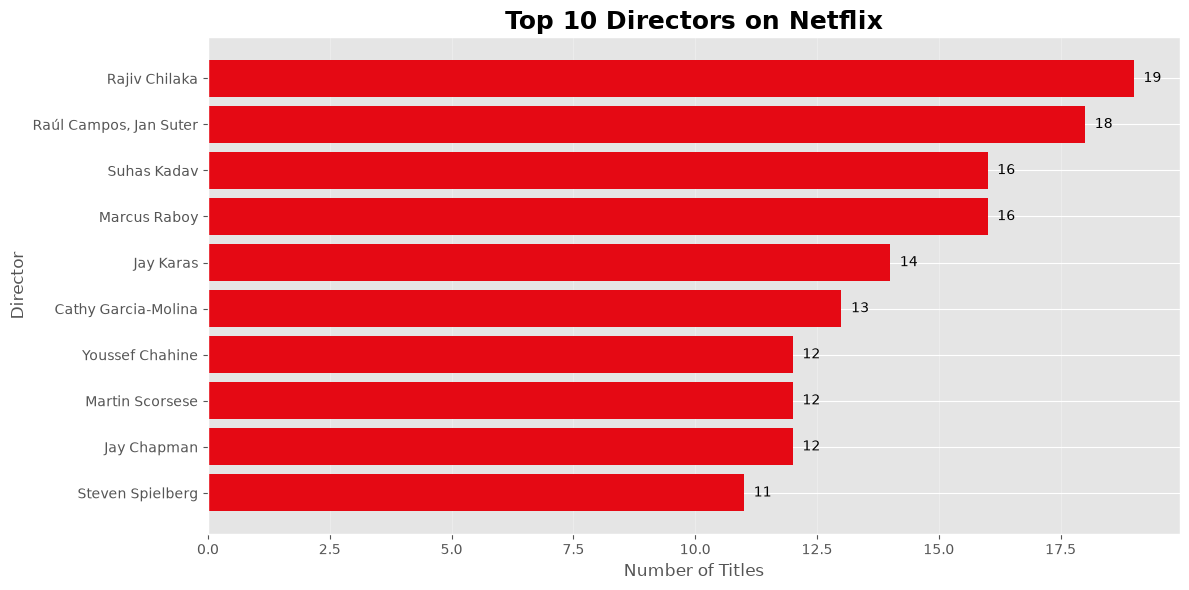

In [28]:
# Remove 'Unknown' directors before analysis
top_directors = (
    df[df['director'] != 'Unknown']['director']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))

bars = plt.barh(
    top_directors.index,
    top_directors.values,
    color="#E50914"
)

plt.title(
    "Top 10 Directors on Netflix",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Number of Titles", fontsize=12)
plt.ylabel("Director", fontsize=12)

# Display values
for bar in bars:
    plt.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height()/2,
        int(bar.get_width()),
        va='center',
        fontsize=10
    )

plt.gca().invert_yaxis()

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()

plt.show()

## Visualization 8: Distribution of Movie Duration

In [29]:
# Select only movies
movies = df[df['type'] == 'Movie'].copy()

# Extract duration in minutes
movies['duration_minutes'] = (
    movies['duration']
    .str.replace(" min", "", regex=False)
    .astype(int)
)

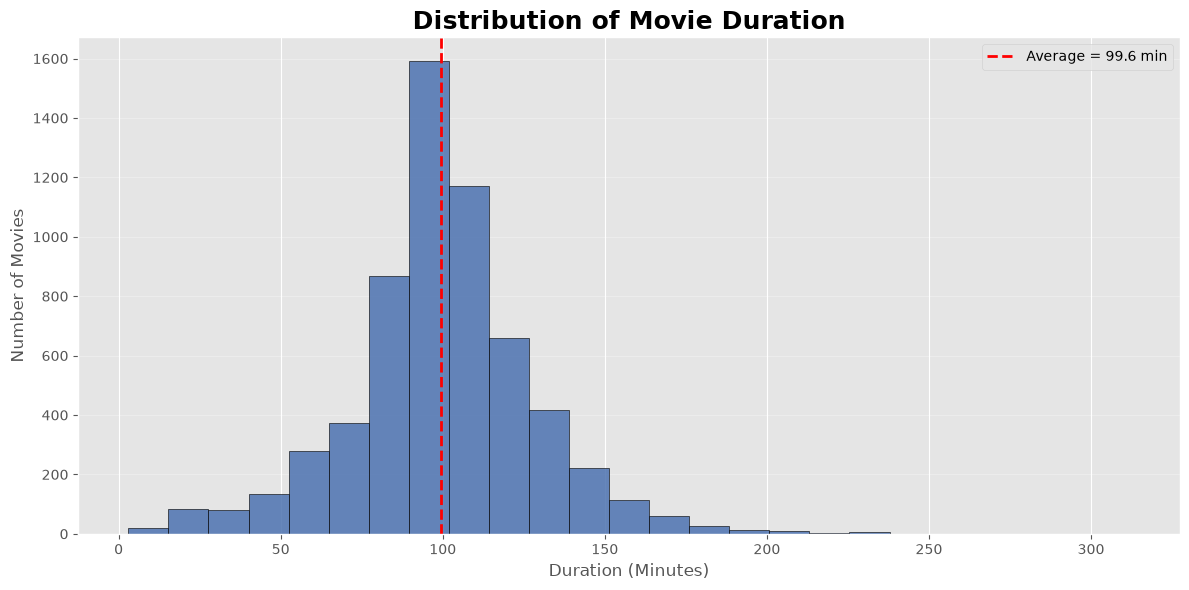

In [30]:
plt.figure(figsize=(12,6))

plt.hist(
    movies['duration_minutes'],
    bins=25,
    color="#4C72B0",
    edgecolor="black",
    alpha=0.85
)

# Average duration line
avg_duration = movies['duration_minutes'].mean()

plt.axvline(
    avg_duration,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Average = {avg_duration:.1f} min"
)

plt.title(
    "Distribution of Movie Duration",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Duration (Minutes)", fontsize=12)
plt.ylabel("Number of Movies", fontsize=12)

plt.grid(axis='y', alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

## Visualization 9: Movie vs TV Show Release Trend

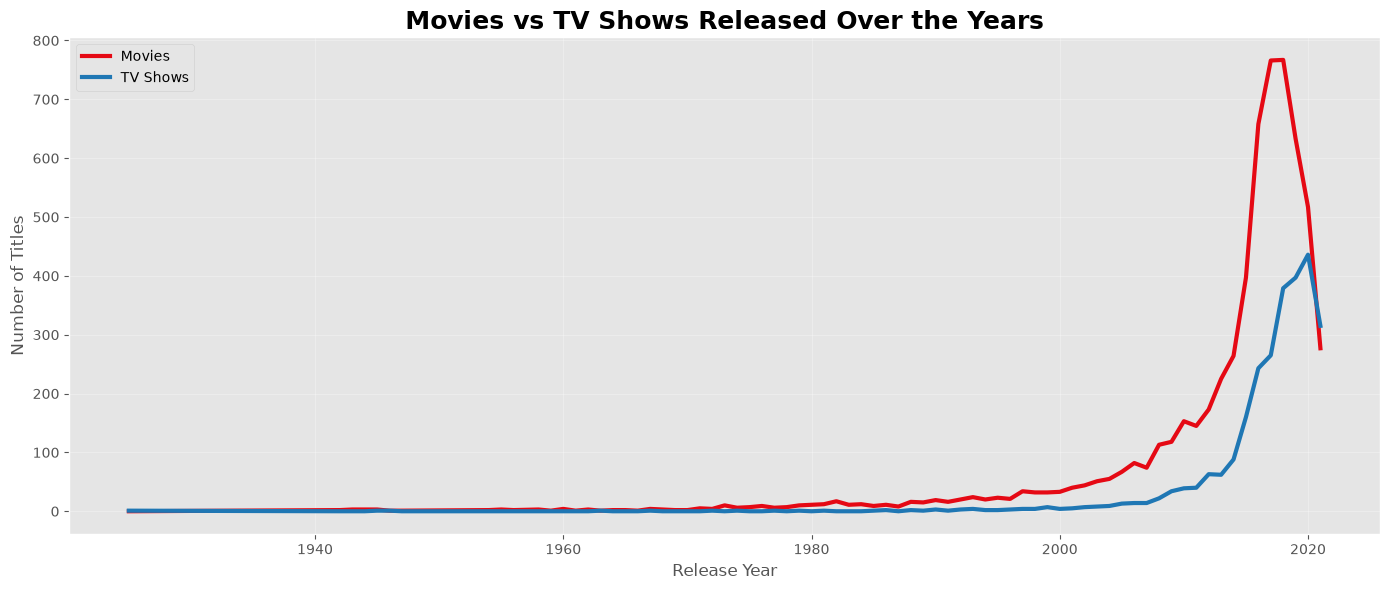

In [31]:
# Count Movies and TV Shows by release year
release_trend = df.groupby(['release_year', 'type']).size().unstack(fill_value=0)

plt.figure(figsize=(14,6))

plt.plot(
    release_trend.index,
    release_trend['Movie'],
    label='Movies',
    linewidth=3,
    color='#E50914'
)

plt.plot(
    release_trend.index,
    release_trend['TV Show'],
    label='TV Shows',
    linewidth=3,
    color='#1F77B4'
)

plt.title(
    "Movies vs TV Shows Released Over the Years",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("Release Year", fontsize=12)
plt.ylabel("Number of Titles", fontsize=12)

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

## Visualization 10: Share of Top 10 Content-Producing Countries

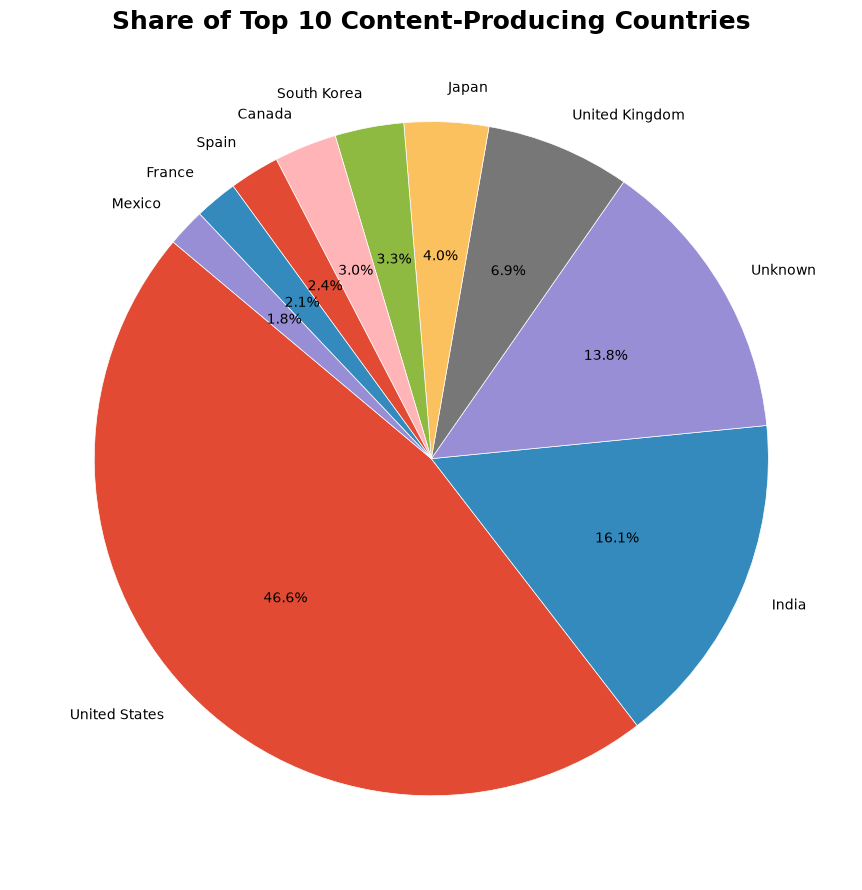

In [32]:
top10 = df['country'].value_counts().head(10)

plt.figure(figsize=(9,9))

plt.pie(
    top10.values,
    labels=top10.index,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor':'white'}
)

plt.title(
    "Share of Top 10 Content-Producing Countries",
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

# Professional Netflix Dashboard

/var/folders/wl/hp1yctjs1pd5wmhh8m51k4340000gn/T/ipykernel_19055/1798558257.py:156: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0,0,1,0.95])
/var/folders/wl/hp1yctjs1pd5wmhh8m51k4340000gn/T/ipykernel_19055/1798558257.py:159: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig(
/Users/snehilchandra/Desktop/Netflix_Data_Cleaning_Project/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


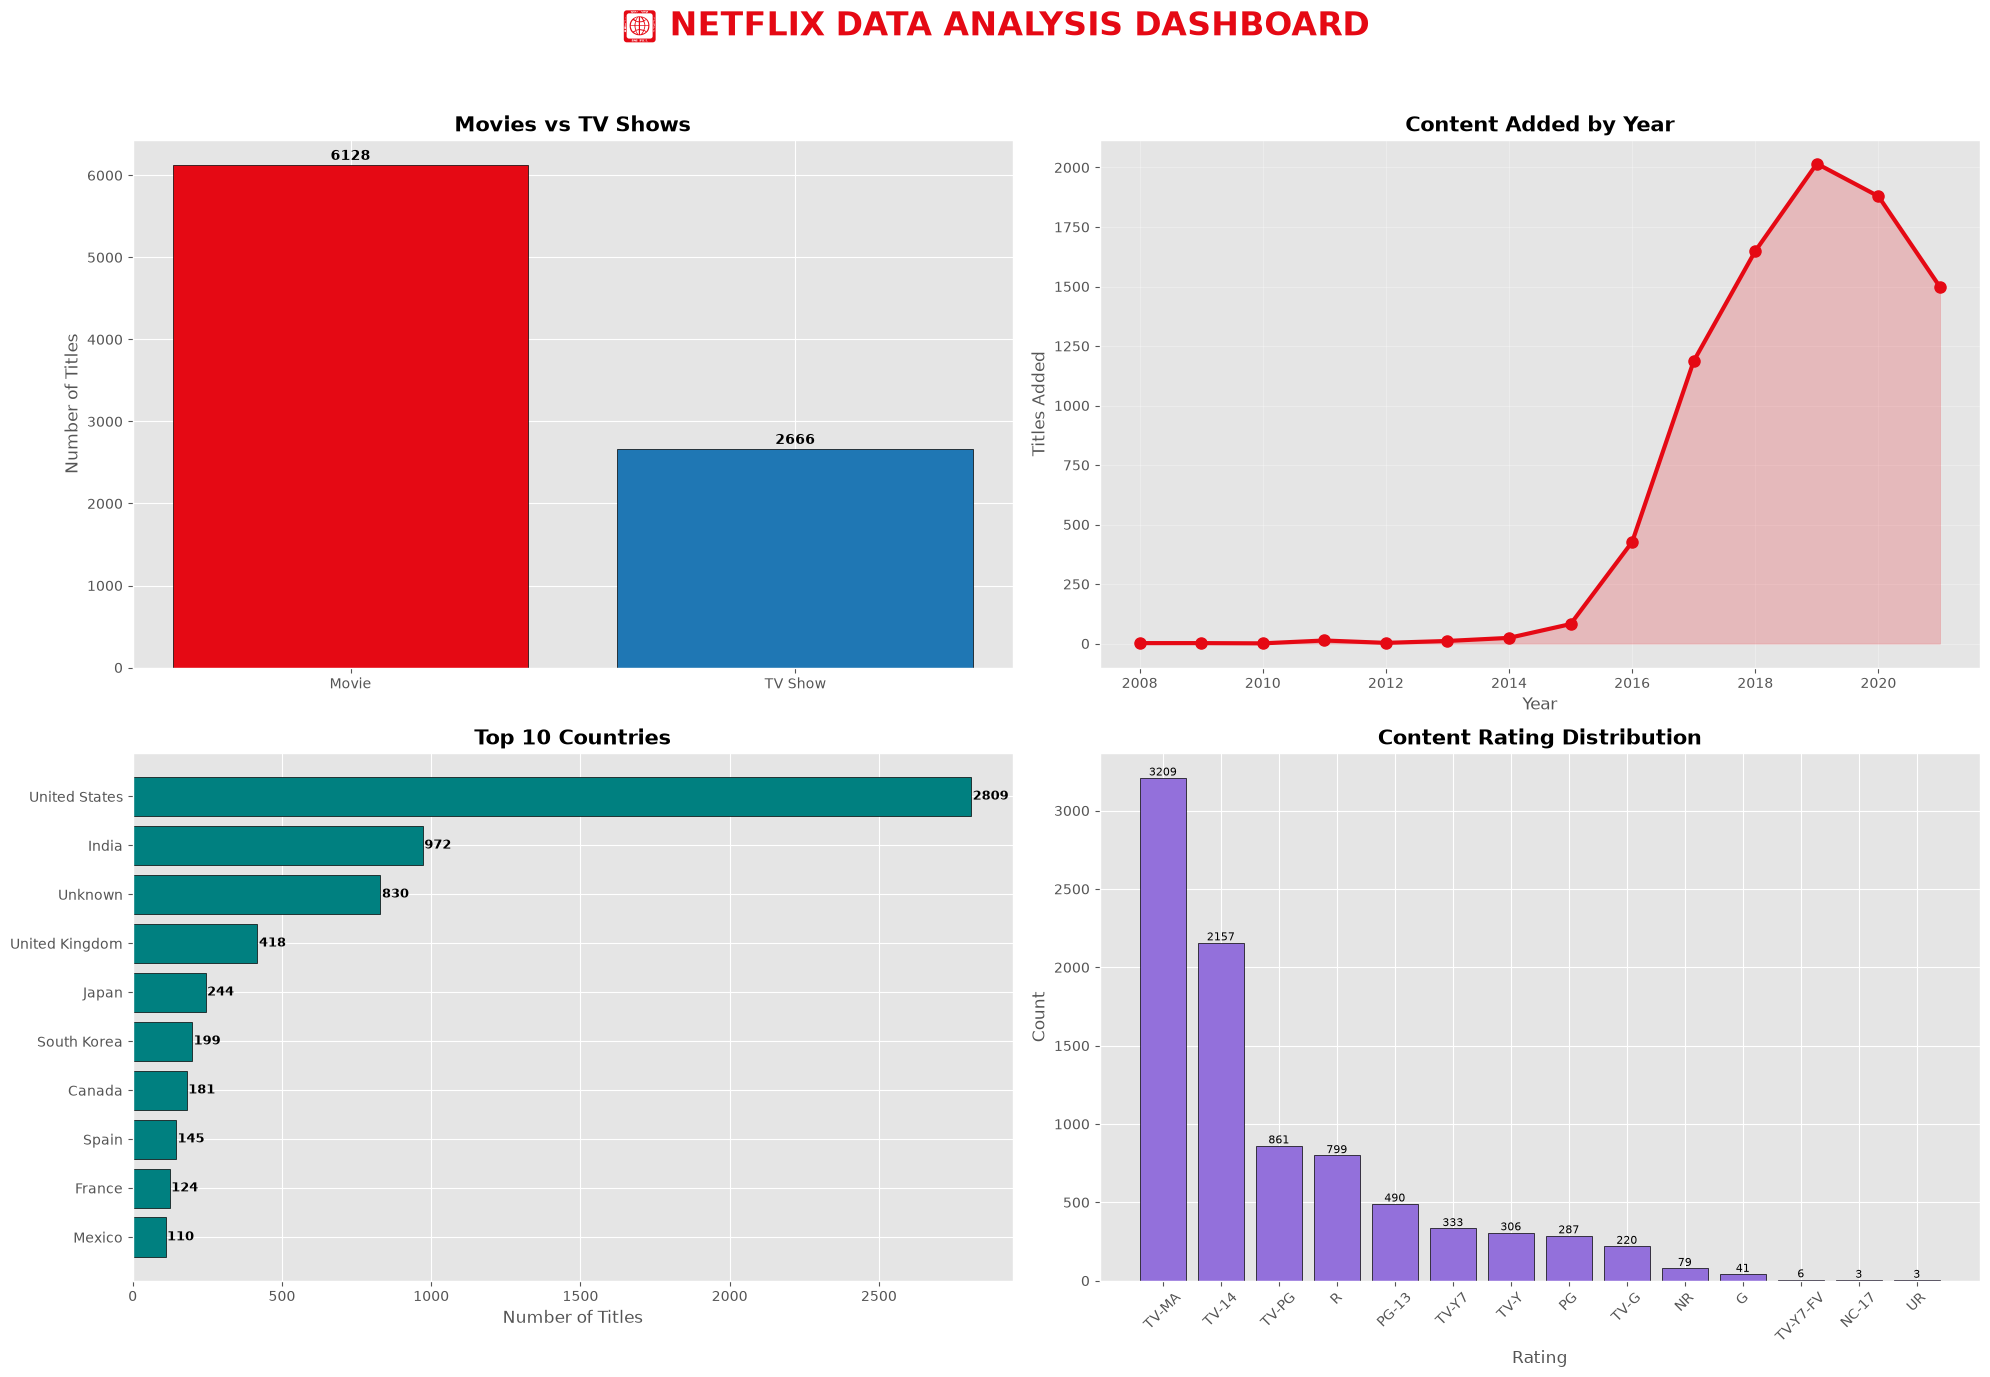

✅ Dashboard saved successfully in images/dashboard.png


In [33]:
# =====================================================
# PROFESSIONAL NETFLIX DASHBOARD
# =====================================================

import matplotlib.pyplot as plt

# Create dashboard
fig, axs = plt.subplots(2, 2, figsize=(20, 14))

# Dashboard Title
fig.suptitle(
    "📊 NETFLIX DATA ANALYSIS DASHBOARD",
    fontsize=24,
    fontweight="bold",
    color="#E50914"
)

# =====================================================
# Dashboard 1 : Movies vs TV Shows
# =====================================================

type_counts = df['type'].value_counts()

bars = axs[0, 0].bar(
    type_counts.index,
    type_counts.values,
    color=["#E50914", "#1F77B4"],
    edgecolor="black"
)

axs[0, 0].set_title(
    "Movies vs TV Shows",
    fontsize=15,
    fontweight="bold"
)

axs[0, 0].set_ylabel("Number of Titles")

for bar in bars:
    axs[0, 0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 60,
        f"{int(bar.get_height())}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

# =====================================================
# Dashboard 2 : Content Added by Year
# =====================================================

year_added = (
    df['date_added']
    .dt.year
    .value_counts()
    .sort_index()
)

axs[0,1].plot(
    year_added.index,
    year_added.values,
    marker='o',
    markersize=8,
    linewidth=3,
    color="#E50914"
)

axs[0,1].fill_between(
    year_added.index,
    year_added.values,
    alpha=0.2,
    color="#E50914"
)

axs[0,1].set_title(
    "Content Added by Year",
    fontsize=15,
    fontweight="bold"
)

axs[0,1].set_xlabel("Year")
axs[0,1].set_ylabel("Titles Added")
axs[0,1].grid(alpha=0.3)

# =====================================================
# Dashboard 3 : Top 10 Countries
# =====================================================

top_country = df['country'].value_counts().head(10)

bars = axs[1,0].barh(
    top_country.index,
    top_country.values,
    color="teal",
    edgecolor="black"
)

axs[1,0].invert_yaxis()

axs[1,0].set_title(
    "Top 10 Countries",
    fontsize=15,
    fontweight="bold"
)

axs[1,0].set_xlabel("Number of Titles")

for bar in bars:
    axs[1,0].text(
        bar.get_width()+5,
        bar.get_y()+bar.get_height()/2,
        f"{int(bar.get_width())}",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

# =====================================================
# Dashboard 4 : Rating Distribution
# =====================================================

rating_counts = df['rating'].value_counts()

bars = axs[1,1].bar(
    rating_counts.index,
    rating_counts.values,
    color="mediumpurple",
    edgecolor="black"
)

axs[1,1].set_title(
    "Content Rating Distribution",
    fontsize=15,
    fontweight="bold"
)

axs[1,1].set_xlabel("Rating")
axs[1,1].set_ylabel("Count")

axs[1,1].tick_params(axis="x", rotation=45)

for bar in bars:
    axs[1,1].text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+15,
        f"{int(bar.get_height())}",
        ha="center",
        fontsize=8
    )

# =====================================================
# Final Layout
# =====================================================

plt.tight_layout(rect=[0,0,1,0.95])

# Save Dashboard
plt.savefig(
    "../images/dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Dashboard saved successfully in images/dashboard.png")

# KPI Summary

In [34]:
# KPI Summary

total_titles = len(df)
movies = (df['type'] == 'Movie').sum()
tvshows = (df['type'] == 'TV Show').sum()
countries = df['country'].nunique()

print("="*50)
print("         NETFLIX DATASET SUMMARY")
print("="*50)
print(f"📺 Total Titles      : {total_titles}")
print(f"🎬 Movies            : {movies}")
print(f"📡 TV Shows          : {tvshows}")
print(f"🌍 Countries         : {countries}")
print("="*50)

         NETFLIX DATASET SUMMARY
📺 Total Titles      : 8794
🎬 Movies            : 6128
📡 TV Shows          : 2666
🌍 Countries         : 749


# Overall Insights

After analyzing the Netflix dataset, the following key insights were observed:

1. Netflix offers significantly more Movies than TV Shows.
2. The number of titles added to Netflix increased rapidly after 2015.
3. The United States contributes the highest amount of content, followed by India and other countries.
4. International Movies, Dramas, and Comedies are among the most popular genres.
5. TV-MA is the most common content rating, indicating a strong focus on mature audiences.
6. Most Netflix movies have a duration between 80 and 120 minutes.
7. The majority of Netflix content has been released after the year 2000.
8. Netflix has expanded its content library considerably in recent years, demonstrating continuous global growth.

# Conclusion

This project focused on cleaning, analyzing, and visualizing the Netflix Movies and TV Shows dataset using Python.

The dataset was successfully cleaned by handling missing values, removing duplicate records, converting data into appropriate formats, and preparing it for analysis.

Exploratory Data Analysis (EDA) was performed to understand the structure and quality of the dataset. A total of ten visualizations and a professional dashboard were created to identify patterns related to content type, release year, ratings, countries, genres, directors, and movie duration.

The analysis revealed that Netflix primarily focuses on movies, has experienced rapid growth in recent years, and offers content from a diverse range of countries.

This project demonstrates practical knowledge of:

- Data Cleaning
- Exploratory Data Analysis (EDA)
- Data Visualization
- Python Programming
- Pandas
- NumPy
- Matplotlib
- Seaborn

Overall, the project successfully transformed raw data into meaningful insights through systematic data analysis and visualization.

# References

## Dataset
Netflix Movies and TV Shows Dataset (CSV)

## Python Libraries
- Pandas
- NumPy
- Matplotlib
- Seaborn

## Development Tools
- Python 3.13
- Visual Studio Code
- Jupyter Notebook

In [35]:
# Export cleaned dataset
df.to_csv("cleaned_netflix_titles.csv", index=False)

print("✅ Cleaned dataset exported successfully!")

✅ Cleaned dataset exported successfully!
